In [1]:
import numpy as np
import pandas as pd

from pathlib import Path

import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.stats import friedmanchisquare, wilcoxon

In [2]:
CellposeSAM_BeforeR = "/mnt/jwh83-data/Confetti/output/Redsea/Clustering/20260119_ns444_cellposeSAM_beforeREDSEA_gnn_predict.csv"
CellposeSAM_AfterR  = "/mnt/jwh83-data/Confetti/output/Redsea/Clustering/20260119_ns444_cellposeSAM_afterREDSEA_gnn_predict.csv"

Mesmer_BeforeR      = "/mnt/jwh83-data/Confetti/output/Redsea/Clustering/20260119_ns444_mesmer_beforeREDSEA_gnn_predict.csv"
Mesmer_AfterR       = "/mnt/jwh83-data/Confetti/output/Redsea/Clustering/20260119_ns444_mesmer_afterREDSEA_gnn_predict.csv"

# Column names
CLUSTER = "leiden"
CTYPE   = "pred_name"
SLIDE   = "slide_name"
CELLID  = "CellID"
XCOL    = "x_centroid"
YCOL    = "y_centroid"

In [3]:
def load_minimal(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    keep = [SLIDE, CELLID, CLUSTER, CTYPE]
    for c in [XCOL, YCOL]:
        if c in df.columns:
            keep.append(c)

    missing = [c for c in [SLIDE, CELLID, CLUSTER, CTYPE] if c not in df.columns]
    if missing:
        raise ValueError(f"{csv_path} missing required columns: {missing}")

    df = df[keep].copy()
    df = df.dropna(subset=[SLIDE, CELLID, CLUSTER, CTYPE])

    # Normalize datatypes
    df[SLIDE] = df[SLIDE].astype(str)
    df[CELLID] = df[CELLID].astype(str)
    df[CLUSTER] = df[CLUSTER].astype(str)
    df[CTYPE] = df[CTYPE].astype(str)
    return df


def cluster_purity_table_from_series(cluster_s: pd.Series, ctype_s: pd.Series) -> pd.DataFrame:
    df = pd.DataFrame({"cluster": cluster_s.astype(str), "ctype": ctype_s.astype(str)})

    ct = df.groupby(["cluster", "ctype"]).size().rename("count").reset_index()
    totals = ct.groupby("cluster")["count"].sum().rename("n_cells").reset_index()

    ct_sorted = ct.sort_values(["cluster", "count"], ascending=[True, False])
    top = (
        ct_sorted.groupby("cluster").head(1)
        .rename(columns={"ctype": "top_celltype", "count": "top_count"})[
            ["cluster", "top_celltype", "top_count"]
        ]
    )

    n_types = ct.groupby("cluster")["ctype"].nunique().rename("n_celltypes").reset_index()

    ct2 = ct.merge(totals, on="cluster", how="left")
    ct2["p"] = ct2["count"] / ct2["n_cells"]
    ct2["term"] = np.where(ct2["p"] > 0, -ct2["p"] * np.log2(ct2["p"]), 0.0)
    ent = ct2.groupby("cluster")["term"].sum().rename("entropy").reset_index()

    out = totals.merge(top, on="cluster").merge(n_types, on="cluster").merge(ent, on="cluster")
    out["purity"] = out["top_count"] / out["n_cells"]
    out = out.sort_values(["purity", "n_cells"], ascending=[False, False]).reset_index(drop=True)
    return out


def overall_weighted_purity(pur_tbl: pd.DataFrame) -> float:
    return float(pur_tbl["top_count"].sum() / pur_tbl["n_cells"].sum())


def composition_matrix(cluster_s: pd.Series, ctype_s: pd.Series):
    tab = pd.crosstab(cluster_s.astype(str), ctype_s.astype(str))
    frac = tab.div(tab.sum(axis=1), axis=0)
    return tab, frac


def hungarian_match_clusters(fracA: pd.DataFrame, fracB: pd.DataFrame) -> pd.DataFrame:
    # Align cell type columns
    all_types = sorted(set(fracA.columns) | set(fracB.columns))
    fracA2 = fracA.reindex(columns=all_types, fill_value=0.0)
    fracB2 = fracB.reindex(columns=all_types, fill_value=0.0)

    sim = cosine_similarity(fracA2.values, fracB2.values)  # nA x nB, higher = more similar
    cost = 1.0 - sim
    row_ind, col_ind = linear_sum_assignment(cost)

    match_df = pd.DataFrame({
        "cluster_A": fracA2.index[row_ind].astype(str),
        "cluster_B": fracB2.index[col_ind].astype(str),
        "cosine_similarity": sim[row_ind, col_ind],
    }).sort_values("cosine_similarity", ascending=False).reset_index(drop=True)

    return match_df


def plot_purity_bars(pur_tbl: pd.DataFrame, title: str, max_clusters: int | None = None):
    d = pur_tbl.copy()
    if max_clusters is not None:
        d = d.head(max_clusters).copy()

    fig, ax = plt.subplots(figsize=(max(10, 0.45 * len(d)), 4))
    ax.bar(d["cluster"].astype(str).values, d["purity"].values)
    ax.set_title(title)
    ax.set_ylabel("Purity (top celltype fraction)")
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis="x", labelrotation=90)
    plt.tight_layout()
    plt.show()


def plot_matched_pair_purities(match_df: pd.DataFrame, topk: int = 30, title: str = ""):
    pairs = match_df.copy().head(topk)
    x = np.arange(len(pairs))
    width = 0.45

    pairs["pair"] = (
        pairs["cluster_A"].astype(str) + " (" + pairs["top_celltype_A"].astype(str) + ")"
        + " ↔ " +
        pairs["cluster_B"].astype(str) + " (" + pairs["top_celltype_B"].astype(str) + ")"
    )

    fig, ax = plt.subplots(figsize=(max(12, 0.7 * len(pairs)), 5))
    ax.bar(x - width/2, pairs["purity_A"].values, width, label="BeforeR purity")
    ax.bar(x + width/2, pairs["purity_B"].values, width, label="AfterR purity")
    ax.set_title(title if title else "Matched cluster pairs: purity comparison (BeforeR vs AfterR)")
    ax.set_ylabel("Purity (top celltype fraction)")
    ax.set_ylim(0, 1.0)
    ax.set_xticks(x)
    ax.set_xticklabels(pairs["pair"].values, rotation=90, ha="center")
    ax.legend()
    plt.tight_layout()
    plt.show()


def holm_adjust(pvals: list[float]) -> list[float]:
    """
    Holm step-down adjustment. Returns adjusted p-values in original order.
    """
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, dtype=float)
    running_max = 0.0
    for i, idx in enumerate(order):
        p = pvals[idx]
        adj_p = (m - i) * p
        running_max = max(running_max, adj_p)
        adj[idx] = min(running_max, 1.0)
    return adj.tolist()


def dominance_probability(x: np.ndarray, y: np.ndarray) -> float:
    """
    P(X > Y) estimated by pairwise comparisons (including ties as 0.5).
    """
    x = np.asarray(x)
    y = np.asarray(y)
    # vectorized pairwise compare could be large; for typical slide counts it's fine.
    gt = (x[:, None] > y[None, :]).mean()
    eq = (x[:, None] == y[None, :]).mean()
    return float(gt + 0.5 * eq)


def per_slide_weighted_purity(df: pd.DataFrame) -> pd.DataFrame:
    """
    For each slide: compute weighted purity across clusters on that slide.
    weighted purity = sum_k max_c n_{k,c} / total cells (on that slide)
    """
    # counts per slide x cluster x celltype
    g = df.groupby([SLIDE, CLUSTER, CTYPE]).size().rename("count").reset_index()

    # cluster totals per slide
    cluster_totals = g.groupby([SLIDE, CLUSTER])["count"].sum().rename("n_cluster").reset_index()

    # majority count per cluster within slide
    g_sorted = g.sort_values([SLIDE, CLUSTER, "count"], ascending=[True, True, False])
    top = g_sorted.groupby([SLIDE, CLUSTER]).head(1).rename(columns={"count": "top_count"})
    top = top[[SLIDE, CLUSTER, "top_count"]]

    # merge and sum within slide
    merged = cluster_totals.merge(top, on=[SLIDE, CLUSTER], how="left")
    per_slide = merged.groupby(SLIDE).agg(
        total_cells=("n_cluster", "sum"),
        total_top=("top_count", "sum"),
        n_clusters=(CLUSTER, "nunique"),
    ).reset_index()

    per_slide["weighted_purity"] = per_slide["total_top"] / per_slide["total_cells"]
    return per_slide

In [4]:
datasets = {
    "CellposeSAM_BeforeR": load_minimal(CellposeSAM_BeforeR),
    "CellposeSAM_AfterR":  load_minimal(CellposeSAM_AfterR),
    "Mesmer_BeforeR":      load_minimal(Mesmer_BeforeR),
    "Mesmer_AfterR":       load_minimal(Mesmer_AfterR),
}

for name, df in datasets.items():
    dups = df.duplicated(subset=[SLIDE, CELLID]).sum()
    print(f"{name}: n={len(df):,} | unique slides={df[SLIDE].nunique():,} | dup (slide,CellID)={dups:,}")



CellposeSAM_BeforeR: n=173,783 | unique slides=8 | dup (slide,CellID)=0
CellposeSAM_AfterR: n=172,465 | unique slides=8 | dup (slide,CellID)=0
Mesmer_BeforeR: n=162,439 | unique slides=8 | dup (slide,CellID)=0
Mesmer_AfterR: n=161,867 | unique slides=8 | dup (slide,CellID)=0


In [5]:
def run_before_after_suite(before_df: pd.DataFrame, after_df: pd.DataFrame, label: str):
    print("\n" + "="*90)
    print(f"{label}: BeforeR vs AfterR")
    print("="*90)

    merged = before_df.merge(after_df, on=[SLIDE, CELLID], how="inner", suffixes=("_A", "_B"))

    print("BeforeR cells:", len(before_df))
    print("AfterR  cells:", len(after_df))
    print("Matched cells (inner join):", len(merged))
    print("Match rate BeforeR:", len(merged) / max(len(before_df), 1))
    print("Match rate AfterR :", len(merged) / max(len(after_df), 1))

    # Purity tables on matched cells only
    purA = cluster_purity_table_from_series(merged[f"{CLUSTER}_A"], merged[f"{CTYPE}_A"])
    purB = cluster_purity_table_from_series(merged[f"{CLUSTER}_B"], merged[f"{CTYPE}_B"])

    overallA = overall_weighted_purity(purA)
    overallB = overall_weighted_purity(purB)
    print(f"\nOverall weighted purity (matched cells only):")
    print(f"  BeforeR={overallA:.4f} | AfterR={overallB:.4f} | (AfterR - BeforeR)={overallB-overallA:+.4f}")

    # Agreement of cluster labels for the same matched cells
    leiden_A = merged[f"{CLUSTER}_A"].astype(str).values
    leiden_B = merged[f"{CLUSTER}_B"].astype(str).values
    ari = adjusted_rand_score(leiden_A, leiden_B)
    nmi = normalized_mutual_info_score(leiden_A, leiden_B)
    print(f"\nLeiden agreement on matched cells:")
    print(f"  ARI={ari:.4f} | NMI={nmi:.4f}")

    # Cluster composition matching (cosine + Hungarian)
    _, fracA = composition_matrix(merged[f"{CLUSTER}_A"], merged[f"{CTYPE}_A"])
    _, fracB = composition_matrix(merged[f"{CLUSTER}_B"], merged[f"{CTYPE}_B"])
    match_df = hungarian_match_clusters(fracA, fracB)

    # Attach purity metadata per cluster
    purA_map = purA.set_index("cluster")[["n_cells","top_celltype","purity","entropy","n_celltypes"]].add_suffix("_A")
    purB_map = purB.set_index("cluster")[["n_cells","top_celltype","purity","entropy","n_celltypes"]].add_suffix("_B")

    match_df = (
        match_df
        .join(purA_map, on="cluster_A")
        .join(purB_map, on="cluster_B")
    )

    match_df["purity_improvement_B_minus_A"] = match_df["purity_B"] - match_df["purity_A"]
    match_df = match_df.sort_values("cosine_similarity", ascending=False).reset_index(drop=True)

    print("\nTop matched cluster pairs by cosine similarity:")
    display(match_df.head(20))

    print("\nTop improvements (AfterR - BeforeR) among matched cluster pairs:")
    display(match_df.sort_values("purity_improvement_B_minus_A", ascending=False).head(20))

    # Plots: overall purity per cluster (top 40 by purity)
    plot_purity_bars(purA, f"{label}: Cluster purity (BeforeR) — matched cells only", max_clusters=40)
    plot_purity_bars(purB, f"{label}: Cluster purity (AfterR) — matched cells only", max_clusters=40)

    # Plot matched pair purities (top 25 by similarity)
    plot_matched_pair_purities(
        match_df,
        topk=25,
        title=f"{label}: Matched clusters (cosine/Hungarian) — purity BeforeR vs AfterR"
    )

    # Plot top improvements
    improve = match_df.sort_values(
        ["purity_improvement_B_minus_A", "cosine_similarity", "n_cells_B"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    topk = min(25, len(improve))
    plot_df = improve.head(topk).copy()
    x = np.arange(topk)

    fig, ax = plt.subplots(figsize=(max(12, 0.7*topk), 5))
    ax.bar(x, plot_df["purity_improvement_B_minus_A"].values)
    ax.axhline(0, linewidth=1)
    ax.set_title(f"{label}: Top {topk} matched cluster pairs by purity improvement (AfterR - BeforeR)")
    ax.set_ylabel("Purity improvement (AfterR - BeforeR)")
    ax.set_xticks(x)
    ax.set_xticklabels(
        (plot_df["cluster_A"].astype(str) + "↔" + plot_df["cluster_B"].astype(str)).values,
        rotation=90
    )
    plt.tight_layout()
    plt.show()

    # Return summary objects for optional downstream use
    return {
        "merged": merged,
        "pur_before": purA,
        "pur_after": purB,
        "match_df": match_df,
        "overall_before": overallA,
        "overall_after": overallB,
        "ari": ari,
        "nmi": nmi,
    }


CellposeSAM: BeforeR vs AfterR
BeforeR cells: 173783
AfterR  cells: 172465
Matched cells (inner join): 172169
Match rate BeforeR: 0.9907125553132354
Match rate AfterR : 0.9982837097382078

Overall weighted purity (matched cells only):
  BeforeR=0.6479 | AfterR=0.6355 | (AfterR - BeforeR)=-0.0124

Leiden agreement on matched cells:
  ARI=0.4706 | NMI=0.6331

Top matched cluster pairs by cosine similarity:


,cluster_A,cluster_B,cosine_similarity,n_cells_A,top_celltype_A,purity_A,entropy_A,n_celltypes_A,n_cells_B,top_celltype_B,purity_B,entropy_B,n_celltypes_B,purity_improvement_B_minus_A
0,39,32,1.000000,375,B,0.994667,0.053278,3,385,B,0.994805,0.052092,3,0.000139
1,17,16,0.999861,1446,Neuroendocrine,0.825726,1.161919,18,1566,Neuroendocrine,0.808429,1.286167,20,-0.017297
2,18,20,0.999860,5953,CD4+ T,0.835041,1.036403,14,5281,CD4+ T,0.832229,1.053380,19,-0.002812
3,20,29,0.999803,4857,CD66+ Epithelial,0.825818,1.088482,17,4619,CD66+ Epithelial,0.829400,1.069351,17,0.003582
4,29,30,0.999731,6671,Plasma,0.939739,0.455928,13,7827,Plasma,0.902645,0.732659,16,-0.037094
5,30,19,0.999729,1762,Smooth muscle,0.977299,0.194803,5,3612,Smooth muscle,0.945460,0.409422,13,-0.031839
6,15,10,0.999611,5580,Smooth muscle,0.967204,0.288361,11,7694,Smooth muscle,0.912139,0.669084,14,-0.055065
7,22,8,0.999512,2064,M2 Macrophage,0.908915,0.609993,8,6153,M2 Macrophage,0.878921,0.882152,19,-0.029994
8,35,25,0.999426,1106,Paneth,0.985533,0.150478,9,1472,Paneth,0.926630,0.576062,12,-0.058903
9,25,15,0.999363,1081,PDPN+ Stromal,0.834413,1.015001,11,1313,PDPN+ Stromal,0.824829,1.156572,15,-0.009584



Top improvements (AfterR - BeforeR) among matched cluster pairs:


,cluster_A,cluster_B,cosine_similarity,n_cells_A,top_celltype_A,purity_A,entropy_A,n_celltypes_A,n_cells_B,top_celltype_B,purity_B,entropy_B,n_celltypes_B,purity_improvement_B_minus_A
26,13,17,0.949683,4802,CD8+ T,0.474594,2.266425,16,6155,CD8+ T,0.743948,1.383385,16,0.269354
29,1,22,0.907816,9493,Goblet,0.338460,2.492819,20,6638,Goblet,0.526363,2.090451,22,0.187903
19,19,28,0.987999,4912,M2 Macrophage,0.565554,2.280274,15,2780,M2 Macrophage,0.699281,1.582556,14,0.133727
24,33,27,0.966466,4770,CD66+ Epithelial,0.477987,1.685921,10,3247,CD66+ Epithelial,0.569141,1.379706,14,0.091153
14,7,4,0.993855,4139,Epithelial,0.715632,1.855870,25,13325,Epithelial,0.766154,1.591237,25,0.050522
11,14,7,0.998694,5930,Plasma,0.815852,1.155600,17,5700,Plasma,0.840000,1.110557,21,0.024148
15,2,6,0.993606,8014,CD36 low Endothelial,0.556651,1.524422,16,11051,CD36 low Endothelial,0.576690,1.721258,20,0.020039
16,21,23,0.993578,1567,Neutrophil,0.365029,2.480595,12,1541,Neutrophil,0.377028,2.650861,17,0.011999
12,9,14,0.997396,4617,Nerve,0.871995,0.816905,15,4750,Nerve,0.876421,0.907192,18,0.004426
17,8,21,0.991158,5723,CD4+ T,0.665909,1.568327,18,6245,CD4+ T,0.669976,1.769824,19,0.004066


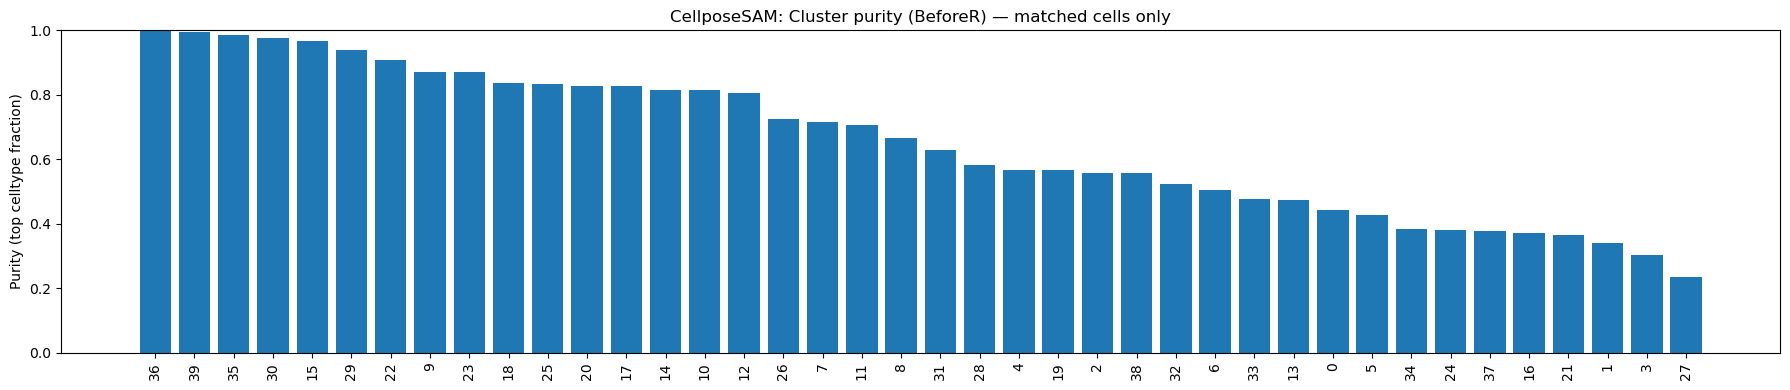

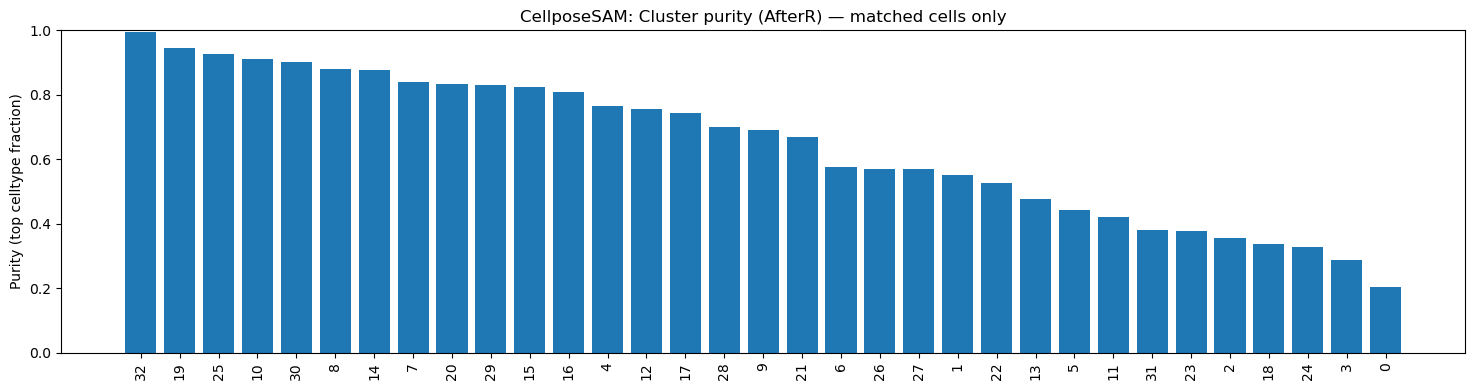

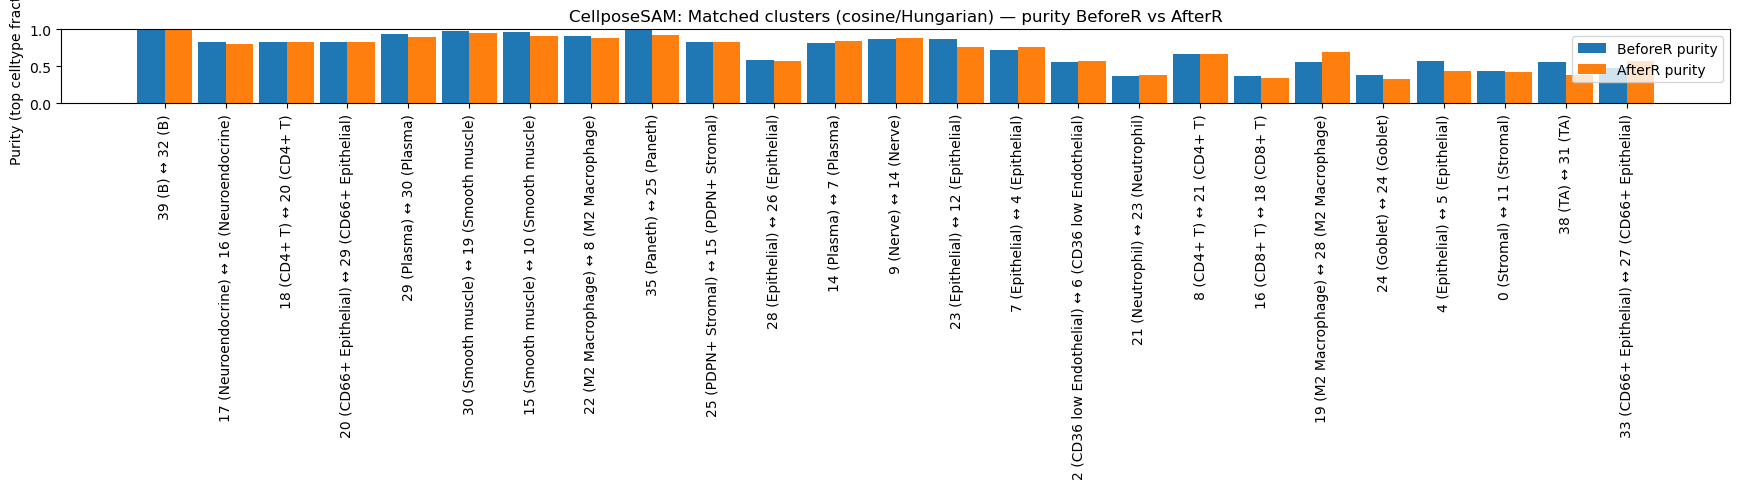

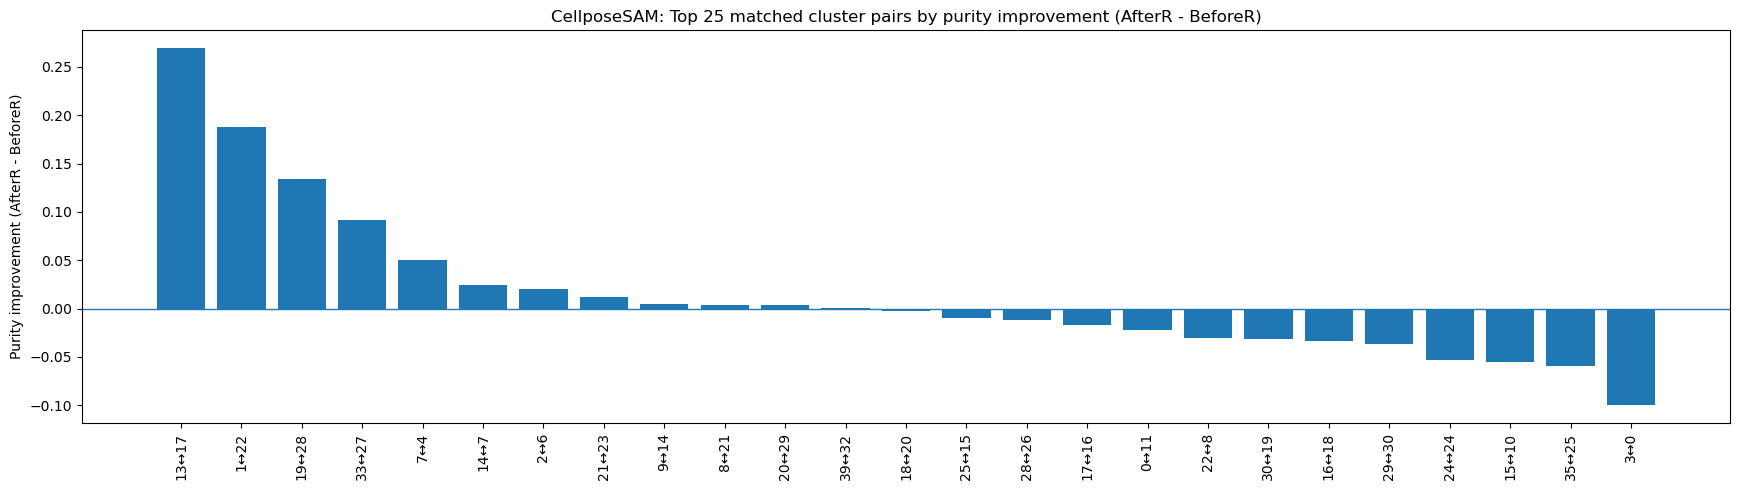


Mesmer: BeforeR vs AfterR
BeforeR cells: 162439
AfterR  cells: 161867
Matched cells (inner join): 161656
Match rate BeforeR: 0.9951797290059653
Match rate AfterR : 0.9986964606745043

Overall weighted purity (matched cells only):
  BeforeR=0.6175 | AfterR=0.6220 | (AfterR - BeforeR)=+0.0045

Leiden agreement on matched cells:
  ARI=0.4645 | NMI=0.6617

Top matched cluster pairs by cosine similarity:


,cluster_A,cluster_B,cosine_similarity,n_cells_A,top_celltype_A,purity_A,entropy_A,n_celltypes_A,n_cells_B,top_celltype_B,purity_B,entropy_B,n_celltypes_B,purity_improvement_B_minus_A
0,38,35,1.000000,271,B,0.996310,0.035137,2,242,B,0.995868,0.038672,2,-0.000442
1,32,31,0.999974,1046,Paneth,0.966539,0.310110,11,1140,Paneth,0.966667,0.310700,12,0.000127
2,18,25,0.999915,1092,Neuroendocrine,0.873626,0.864116,15,1102,Neuroendocrine,0.867514,0.914304,14,-0.006113
3,33,30,0.999913,2930,Smooth muscle,0.973379,0.217052,7,2888,Smooth muscle,0.974377,0.238553,9,0.000998
4,15,15,0.999868,4429,Smooth muscle,0.964778,0.294725,11,7608,Smooth muscle,0.958070,0.354346,17,-0.006707
5,31,34,0.999773,1900,Epithelial,0.628947,1.385109,15,1855,Epithelial,0.642588,1.288208,16,0.013640
6,19,11,0.999508,4902,CD4+ T,0.815177,1.118944,17,5032,CD4+ T,0.818362,1.149100,20,0.003185
7,30,26,0.999437,2010,Smooth muscle,0.955721,0.276274,5,2240,Smooth muscle,0.904018,0.605921,10,-0.051704
8,10,18,0.999397,3220,Nerve,0.901242,0.730344,13,3394,Nerve,0.941072,0.423177,13,0.039830
9,24,17,0.999065,1367,PDPN+ Stromal,0.809071,1.121960,11,1630,PDPN+ Stromal,0.752761,1.393749,14,-0.056310



Top improvements (AfterR - BeforeR) among matched cluster pairs:


,cluster_A,cluster_B,cosine_similarity,n_cells_A,top_celltype_A,purity_A,entropy_A,n_celltypes_A,n_cells_B,top_celltype_B,purity_B,entropy_B,n_celltypes_B,purity_improvement_B_minus_A
30,29,2,0.780732,2693,CD36 low Endothelial,0.504270,1.185586,7,4202,CD36 low Endothelial,0.879343,0.810616,15,0.375073
23,4,23,0.940633,11884,Plasma,0.492595,2.434602,22,8720,Plasma,0.863417,0.914138,16,0.370822
24,17,21,0.921317,3677,Stromal,0.477019,2.207479,14,1793,Stromal,0.680982,1.390329,12,0.203962
20,9,10,0.974111,3182,M2 Macrophage,0.734758,1.367639,14,4239,M2 Macrophage,0.884879,0.774519,16,0.150120
29,0,1,0.793408,4885,CD4+ T,0.212078,3.393494,25,6374,DC,0.310951,2.826273,23,0.098873
8,10,18,0.999397,3220,Nerve,0.901242,0.730344,13,3394,Nerve,0.941072,0.423177,13,0.039830
18,25,33,0.985100,838,MUC1+ Epithelial,0.356802,2.446445,16,759,TA,0.392622,2.300580,16,0.035820
35,5,13,0.436341,7351,CD8+ T,0.339546,2.702722,17,4607,Stromal,0.368570,2.851115,21,0.029024
22,21,19,0.949066,2581,Epithelial,0.715614,1.483885,23,5795,Epithelial,0.732183,1.277913,23,0.016569
5,31,34,0.999773,1900,Epithelial,0.628947,1.385109,15,1855,Epithelial,0.642588,1.288208,16,0.013640


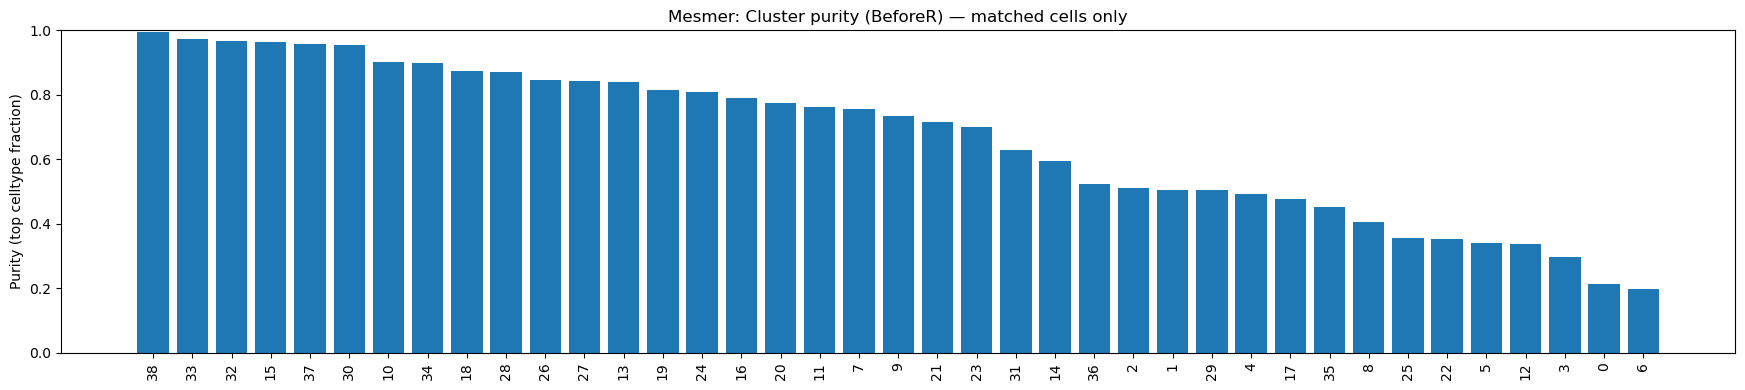

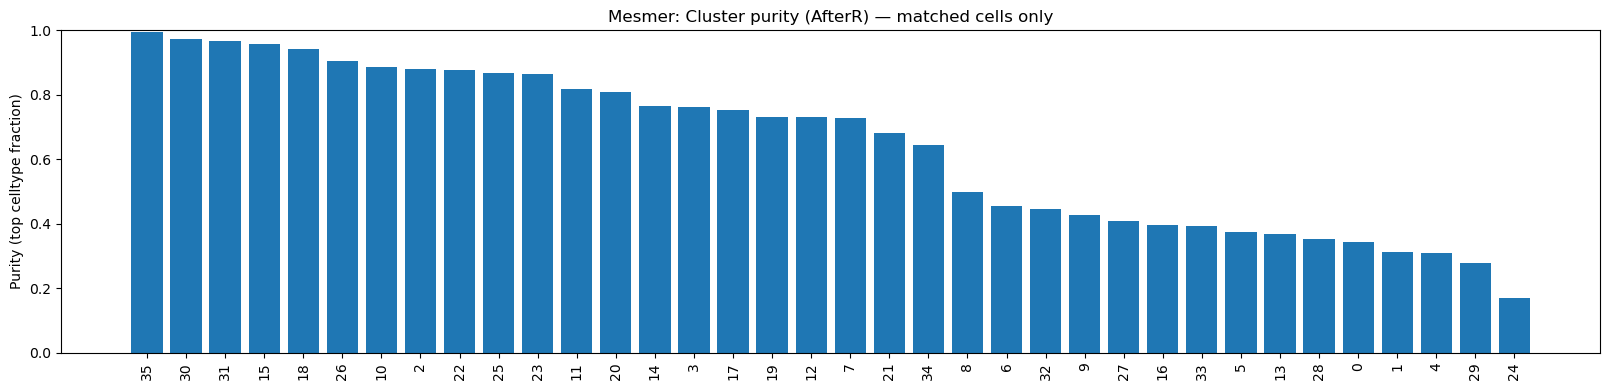

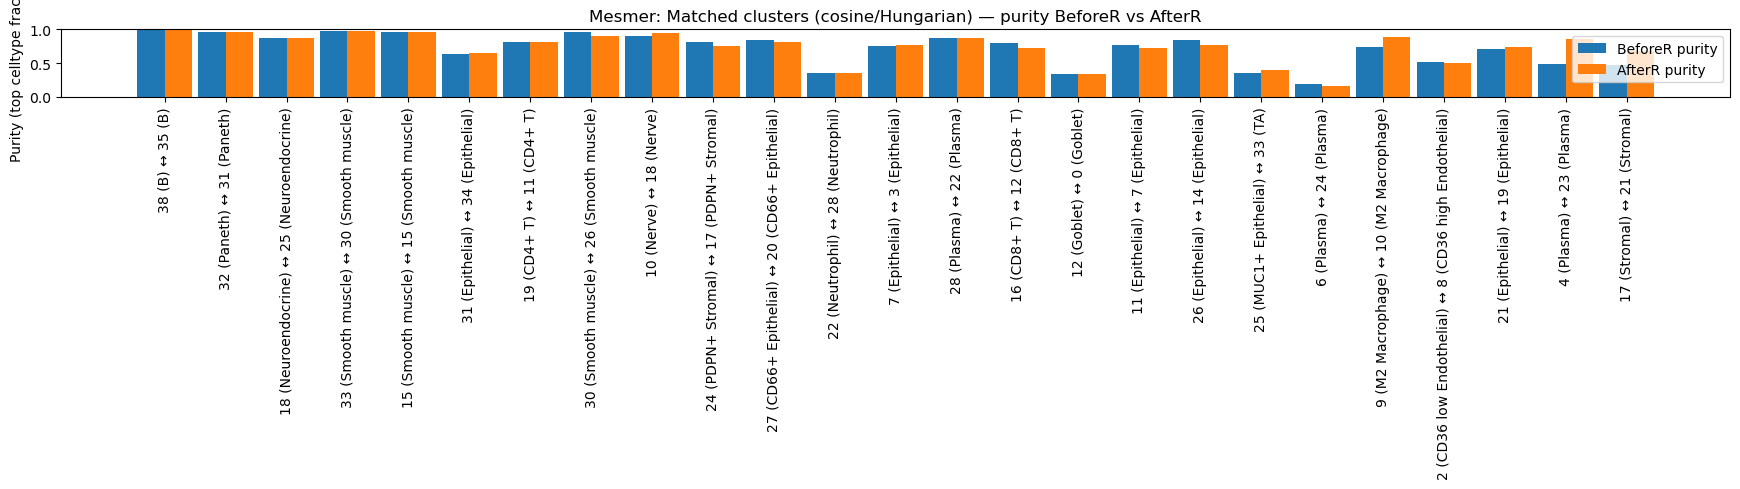

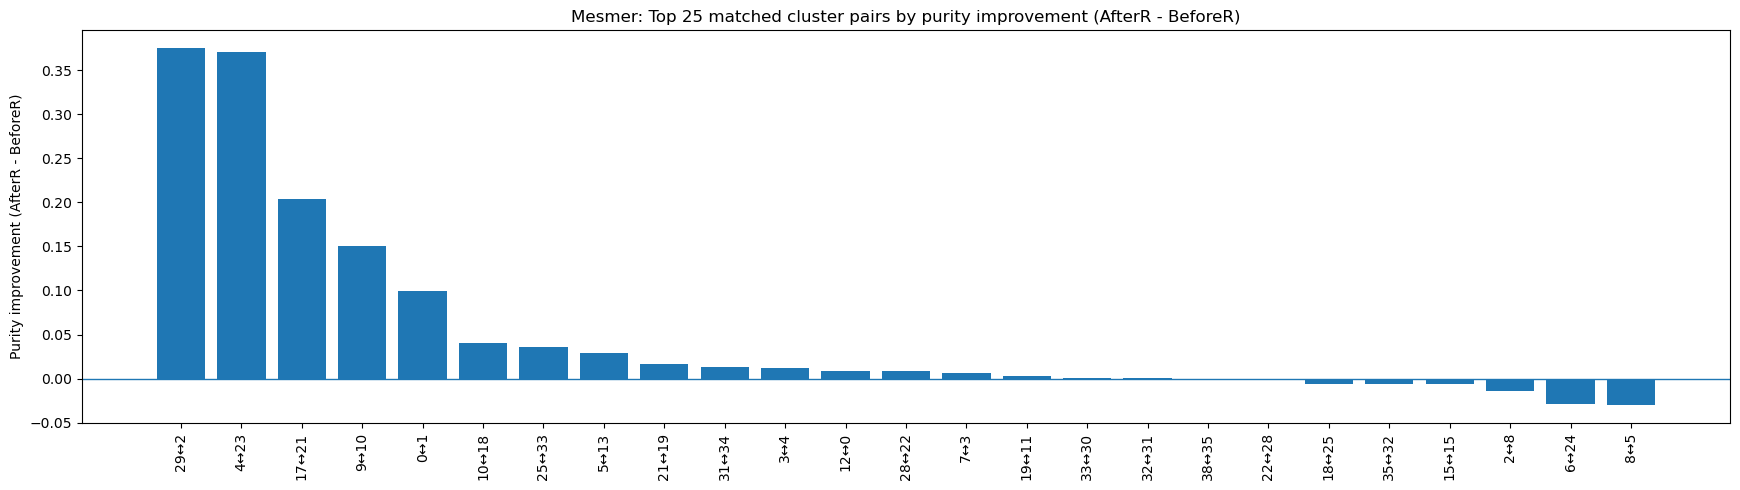

In [6]:
cellposesam_res = run_before_after_suite(
    datasets["CellposeSAM_BeforeR"],
    datasets["CellposeSAM_AfterR"],
    label="CellposeSAM"
)

mesmer_res = run_before_after_suite(
    datasets["Mesmer_BeforeR"],
    datasets["Mesmer_AfterR"],
    label="Mesmer"
)

,slide_name,total_cells,total_top,n_clusters,weighted_purity,method
0,B004-A-004,14414,9045,35,0.627515,CellposeSAM_BeforeR
1,B004-A-008,24138,13930,39,0.577098,CellposeSAM_BeforeR
2,B004-A-104,27049,17533,35,0.648194,CellposeSAM_BeforeR
3,B004-A-204,14776,10522,35,0.712101,CellposeSAM_BeforeR
4,B004-A-304,14148,9318,36,0.658609,CellposeSAM_BeforeR



Slides total: 8
Missingness per method:
method
CellposeSAM_AfterR     0
CellposeSAM_BeforeR    0
Mesmer_AfterR          0
Mesmer_BeforeR         0
dtype: int64

Slides with all four methods available: 8


method,CellposeSAM_AfterR,CellposeSAM_BeforeR,Mesmer_AfterR,Mesmer_BeforeR
slide_name,,,,
B004-A-004,0.608608,0.627515,0.626399,0.630496
B004-A-008,0.554184,0.577098,0.583631,0.542184
B004-A-104,0.636898,0.648194,0.611394,0.641211
B004-A-204,0.703813,0.712101,0.684336,0.683112
B004-A-304,0.646084,0.658609,0.646548,0.599171


,mean,median,std,min,max,n_slides
method,,,,,,
CellposeSAM_AfterR,0.645303,0.655782,0.046560,0.554184,0.703813,8
CellposeSAM_BeforeR,0.657541,0.655240,0.043075,0.577098,0.712101,8
Mesmer_BeforeR,0.635176,0.641133,0.047148,0.542184,0.687913,8
Mesmer_AfterR,0.637462,0.638104,0.031687,0.583631,0.684336,8


/tmp/ipykernel_298293/1322350545.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([wide_complete[c].values for c in wide_complete.columns], labels=wide_complete.columns, vert=True)


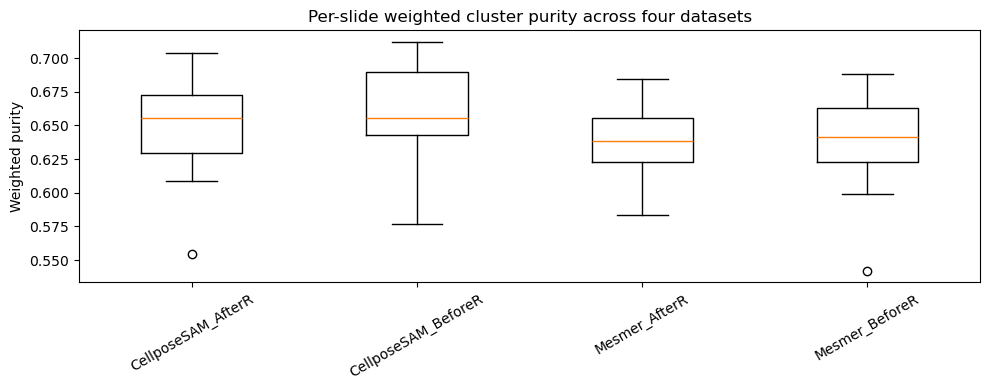

In [7]:
per_slide = []
for name, df in datasets.items():
    ps = per_slide_weighted_purity(df)
    ps["method"] = name
    per_slide.append(ps)

per_slide_df = pd.concat(per_slide, ignore_index=True)
display(per_slide_df.head())

# Pivot to slides x methods
wide = per_slide_df.pivot(index=SLIDE, columns="method", values="weighted_purity")

print("\nSlides total:", wide.shape[0])
print("Missingness per method:")
print(wide.isna().sum().sort_values(ascending=False))

# Use only slides present in all 4 for paired testing
wide_complete = wide.dropna(axis=0, how="any").copy()

print("\nSlides with all four methods available:", wide_complete.shape[0])
display(wide_complete.head())


# %%
# Descriptive summaries
summ = wide_complete.agg(["mean", "median", "std", "min", "max"]).T.sort_values("median", ascending=False)
summ["n_slides"] = wide_complete.shape[0]
display(summ)

# Quick boxplot (per-slide weighted purity distributions)
fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot([wide_complete[c].values for c in wide_complete.columns], labels=wide_complete.columns, vert=True)
ax.set_title("Per-slide weighted cluster purity across four datasets")
ax.set_ylabel("Weighted purity")
ax.tick_params(axis="x", labelrotation=30)
plt.tight_layout()
plt.show()

In [9]:
cols = list(wide_complete.columns)

pairs = []
pvals = []

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        a = cols[i]
        b = cols[j]
        x = wide_complete[a].values
        y = wide_complete[b].values
        diff = x - y

        # Wilcoxon signed-rank on paired differences; handle all-zero differences
        if np.allclose(diff, 0):
            pval = 1.0
            stat = 0.0
        else:
            # zero_method='wilcox' drops zero diffs; alternative='two-sided'
            stat, pval = wilcoxon(x, y, zero_method="wilcox", alternative="two-sided")

        pairs.append((a, b))
        pvals.append(float(pval))

p_adj = holm_adjust(pvals)

rows = []
for (a, b), pv, pv_adj in zip(pairs, pvals, p_adj):
    x = wide_complete[a].values
    y = wide_complete[b].values
    rows.append({
        "A": a,
        "B": b,
        "median_diff(A-B)": float(np.median(x - y)),
        "mean_diff(A-B)": float(np.mean(x - y)),
        "dominance_P(A>B)": dominance_probability(x, y),
        "p_value": pv,
        "p_adj_holm": pv_adj,
        "reject_0.05": pv_adj < 0.05,
    })

posthoc = pd.DataFrame(rows).sort_values(["p_adj_holm", "p_value", "dominance_P(A>B)"], ascending=[True, True, False])
display(posthoc)


,A,B,median_diff(A-B),mean_diff(A-B),dominance_P(A>B),p_value,p_adj_holm,reject_0.05
4,CellposeSAM_BeforeR,Mesmer_BeforeR,0.019903,0.022365,0.656250,0.015625,0.093750,False
3,CellposeSAM_BeforeR,Mesmer_AfterR,0.024987,0.020079,0.671875,0.023438,0.117188,False
0,CellposeSAM_AfterR,CellposeSAM_BeforeR,-0.015716,-0.012238,0.421875,0.148438,0.593750,False
2,CellposeSAM_AfterR,Mesmer_BeforeR,0.010606,0.010127,0.578125,0.382812,1.000000,False
1,CellposeSAM_AfterR,Mesmer_AfterR,0.009391,0.007841,0.593750,0.460938,1.000000,False
5,Mesmer_AfterR,Mesmer_BeforeR,-0.003755,0.002286,0.468750,0.843750,1.000000,False


,method,slide_wins,win_rate
1,CellposeSAM_BeforeR,5.0,0.625
0,CellposeSAM_AfterR,1.0,0.125
2,Mesmer_AfterR,1.0,0.125
3,Mesmer_BeforeR,1.0,0.125


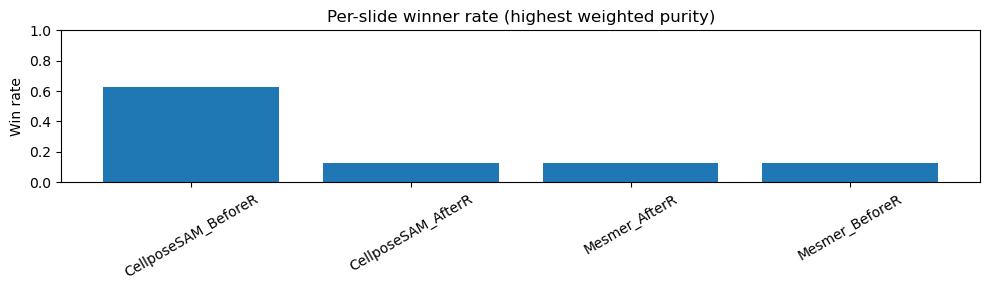

In [10]:
vals = wide_complete.copy()
methods = vals.columns.tolist()

wins = {m: 0.0 for m in methods}
for slide, row in vals.iterrows():
    best = row.max()
    winners = row.index[row == best].tolist()
    for w in winners:
        wins[w] += 1.0 / len(winners)

wins_df = pd.DataFrame({"method": list(wins.keys()), "slide_wins": list(wins.values())})
wins_df["win_rate"] = wins_df["slide_wins"] / len(vals)
wins_df = wins_df.sort_values("slide_wins", ascending=False)
display(wins_df)

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(wins_df["method"].values, wins_df["win_rate"].values)
ax.set_title("Per-slide winner rate (highest weighted purity)")
ax.set_ylabel("Win rate")
ax.set_ylim(0, 1.0)
ax.tick_params(axis="x", labelrotation=30)
plt.tight_layout()
plt.show()

,mean,median,std,min,max
method,,,,,
CellposeSAM_AfterR,-0.385606,-0.370731,0.091743,-0.569783,-0.270457
Mesmer_BeforeR,-0.439113,-0.425352,0.064911,-0.523195,-0.342984
Mesmer_AfterR,-0.410137,-0.434906,0.060244,-0.471925,-0.326302
CellposeSAM_BeforeR,-0.474041,-0.476064,0.066621,-0.571858,-0.362914


/tmp/ipykernel_298293/2491788600.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([sil_wide_complete[c].values for c in sil_wide_complete.columns],


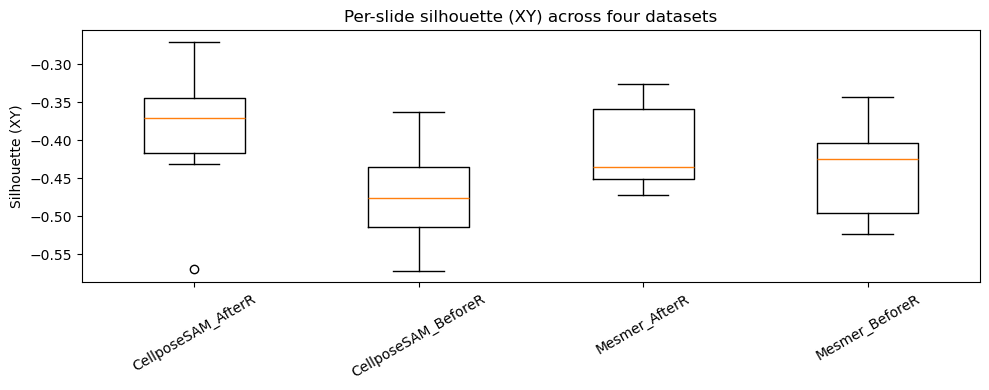

Friedman test (silhouette_xy): chi2=10.9500, p=0.0119993


,A,B,median_diff(A-B),dominance_P(A>B),p_value,p_adj_holm,reject_0.05
0,CellposeSAM_AfterR,CellposeSAM_BeforeR,0.071273,0.812500,0.007812,0.046875,True
2,CellposeSAM_AfterR,Mesmer_BeforeR,0.051288,0.718750,0.054688,0.273438,False
5,Mesmer_AfterR,Mesmer_BeforeR,0.051614,0.609375,0.109375,0.437500,False
3,CellposeSAM_BeforeR,Mesmer_AfterR,-0.070203,0.250000,0.195312,0.585938,False
1,CellposeSAM_AfterR,Mesmer_AfterR,0.030184,0.656250,0.382812,0.765625,False
4,CellposeSAM_BeforeR,Mesmer_BeforeR,-0.012764,0.328125,0.382812,0.765625,False


In [12]:

from sklearn.metrics import silhouette_score
from scipy.stats import friedmanchisquare, wilcoxon

def per_slide_silhouette_xy(df, sample_cap=20000, min_cells=30, random_state=0):
    if XCOL not in df.columns or YCOL not in df.columns:
        raise ValueError(f"Missing {XCOL}/{YCOL} in dataframe; cannot compute XY silhouette.")

    rows = []
    for slide, g in df.groupby(SLIDE):
        gg = g[[XCOL, YCOL, CLUSTER]].dropna()
        if len(gg) < min_cells or gg[CLUSTER].nunique() < 2:
            continue

        if sample_cap is not None and len(gg) > sample_cap:
            gg = gg.sample(sample_cap, random_state=random_state)

        X = gg[[XCOL, YCOL]].to_numpy(dtype=float)
        y = gg[CLUSTER].astype(str).to_numpy()

        try:
            s = float(silhouette_score(X, y, metric="euclidean"))
        except Exception:
            continue

        rows.append({SLIDE: str(slide), "silhouette_xy": s})

    return pd.DataFrame(rows)

# ---- RUN + COMPARE (requires: datasets dict, SLIDE/CLUSTER/XCOL/YCOL, holm_adjust, dominance_probability) ----
sil_long = []
for name, df in datasets.items():
    sd = per_slide_silhouette_xy(df, sample_cap=20000, min_cells=30, random_state=0)
    sd["method"] = name
    sil_long.append(sd)

sil_long = pd.concat(sil_long, ignore_index=True)
sil_wide = sil_long.pivot(index=SLIDE, columns="method", values="silhouette_xy")
sil_wide_complete = sil_wide.dropna(axis=0, how="any").copy()

# Summary + boxplot
display(sil_wide_complete.agg(["mean", "median", "std", "min", "max"]).T.sort_values("median", ascending=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot([sil_wide_complete[c].values for c in sil_wide_complete.columns],
           labels=sil_wide_complete.columns, vert=True)
ax.set_title("Per-slide silhouette (XY) across four datasets")
ax.set_ylabel("Silhouette (XY)")
ax.tick_params(axis="x", labelrotation=30)
plt.tight_layout()
plt.show()

# Friedman
cols = list(sil_wide_complete.columns)
data_cols = [sil_wide_complete[c].values for c in cols]
if sil_wide_complete.shape[0] >= 3:
    stat, p = friedmanchisquare(*data_cols)
    print(f"Friedman test (silhouette_xy): chi2={stat:.4f}, p={p:.6g}")
else:
    print("Not enough complete slides for Friedman (need >=3).")

# Post-hoc Wilcoxon + Holm
pairs, pvals = [], []
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        a, b = cols[i], cols[j]
        x = sil_wide_complete[a].values
        y = sil_wide_complete[b].values
        diff = x - y
        if np.allclose(diff, 0):
            pv = 1.0
        else:
            _, pv = wilcoxon(x, y, zero_method="wilcox", alternative="two-sided")
        pairs.append((a, b))
        pvals.append(float(pv))

p_adj = holm_adjust(pvals)

rows = []
for (a, b), pv, pv_adj in zip(pairs, pvals, p_adj):
    x = sil_wide_complete[a].values
    y = sil_wide_complete[b].values
    rows.append({
        "A": a,
        "B": b,
        "median_diff(A-B)": float(np.median(x - y)),
        "dominance_P(A>B)": dominance_probability(x, y),
        "p_value": pv,
        "p_adj_holm": pv_adj,
        "reject_0.05": pv_adj < 0.05,
    })

sil_posthoc = pd.DataFrame(rows).sort_values(["p_adj_holm", "p_value"], ascending=[True, True])
display(sil_posthoc)
